# KPIs Mensais de Rede de Telecom: Barras de Uso de Dados com Linhas de ARPU e Cancelamento (PROC GBARLINE)

## Resumo Executivo

Este notebook usa **PROC GBARLINE** para combinar um gráfico de barras verticais do uso mensal de dados móveis com gráficos de linha sobrepostos de ARPU, cancelamento e chamados de suporte — o clássico painel de KPIs de "dois eixos" que um analista de telecom monta para verificar se o aumento no uso realmente se traduz em receita e retenção. Ele gera registros sintéticos por assinante inline e então exercita as instruções BAR e LINE com subgrupos, eixos direitos personalizados, símbolos de referência e legendas.

## Fontes de Dados

**Conjunto de dados: `telco_kpi`** — registros sintéticos por assinante-mês (4 meses x 3 níveis de plano x 8 assinantes = 96 linhas), gerados inline com `call streaminit(20260531)`. O painel é mantido em 96 linhas para caber confortavelmente dentro do limite de 100 observações do modo sem licença, deixando cada mês e nível de plano totalmente povoados.

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `month`  | Char | Rótulo do mês do calendário (Jan–Abr) |
| `plan`   | Char | Nível de plano: Pré-pago, Pós-pago, Família |
| `data_gb`| Num  | Dados móveis mensais consumidos, em GB (distribuição gama, com leve repique sazonal e crescimento lento) |
| `arpu`   | Num  | Receita média por usuário, em USD (sobe com o nível de plano e ao longo dos meses) |
| `churn`  | Num  | Indicador de cancelamento mensal (0/1, Bernoulli; mais alto no início do período e em níveis mais baixos) |
| `tickets`| Num  | Chamados de suporte abertos (contagem de Poisson) |

# KPIs Mensais de Rede de Telecom com PROC GBARLINE

Operadoras de telecom vivem e morrem por um punhado de KPIs mensais: quanto de **dados** os assinantes consomem, o **ARPU** (receita média por usuário) que esse consumo gera, quantos clientes **cancelam**, e a carga de **chamados de suporte** por trás de tudo isso. Essas métricas vivem em escalas muito diferentes — gigabytes, dólares e pequenas contagens — então plotá-las em um único eixo de resposta esconde a história.

`PROC GBARLINE` foi feito exatamente para isso: desenha um gráfico de **barras** verticais contra o eixo esquerdo e sobrepõe uma ou mais **linhas** contra um eixo direito independente. Neste notebook construímos um painel de uso vs. receita, e então progressivamente incluímos subgrupos em nível de plano, um eixo direito personalizado e sobreposições de múltiplas linhas.

## Passo 1 — Gerar dados sintéticos de assinante-mês

O data step abaixo fabrica um painel realista: 4 meses (Jan–Abr) em 3 níveis de plano (Pré-pago, Pós-pago, Família) com 8 assinantes cada, totalizando 96 linhas. Semeamos o gerador de números aleatórios com `call streaminit` para reprodutibilidade e sorteamos cada KPI de uma distribuição apropriada ao domínio:

- **Uso de dados** de uma distribuição gama com leve repique sazonal e crescimento lento mês a mês.
- **ARPU** subindo com o nível de plano e ao longo dos meses, com ruído normal.
- **Cancelamento** como um indicador de Bernoulli mais alto no início do período e em níveis mais baratos.
- **Chamados de suporte** como contagens de Poisson, levemente mais pesadas no início.

Nenhum arquivo externo é lido — tudo é autocontido, e o painel de 96 linhas permanece dentro do limite sem licença de 100 observações, então cada mês e nível renderiza.

In [1]:
DADOS telco_kpi;
    CHAMAR streaminit(20260531);
    COMPRIMENTO month $3 plan $12;
    VETOR mname[4] $3 _temporary_
        ('Jan' 'Fev' 'Mar' 'Abr');
    FAZER mi = 1 ATÉ 4;
        month = mname[mi];
        /* leve repique sazonal e crescimento lento dos dados */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        FAZER plan_i = 1 ATÉ 3;
            SE plan_i = 1 ENTÃO plan = 'Pré-pago';
            SENÃO SE plan_i = 2 ENTÃO plan = 'Pós-pago';
            SENÃO plan = 'Família';
            FAZER rep = 1 ATÉ 8;
                /* dados móveis mensais consumidos (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* receita média por usuário ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* indicador de cancelamento mensal, mais alto no inicio do ano */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* chamados de suporte abertos */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                SAÍDA;
            FIM;
        FIM;
    FIM;
    REMOVER mi plan_i rep season mname:;
EXECUTAR;


NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Passo 2 — O painel principal: barras de uso + linha de ARPU

Este é o padrão canônico do `GBARLINE`. A instrução `BAR` plota o uso médio mensal de dados (`SUMVAR=data_gb TYPE=mean`), e uma única instrução `LINE` sobrepõe o ARPU médio no eixo direito (`STAT=mean TYPE=join`). Ativamos o ODS Graphics e damos ao gráfico um título de duas linhas. `COUTLINE=` e `WIDTH=` ajustam as barras.

                                           Uso Mensal de Dados Móveis e ARPU                                            
                                      KPIs sintéticos de rede de telecomunicações                                       




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Uso Mensal de Dados Móveis e ARPU.
NOTE: Option TITLE2 changed to KPIs sintéticos de rede de telecomunicações.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


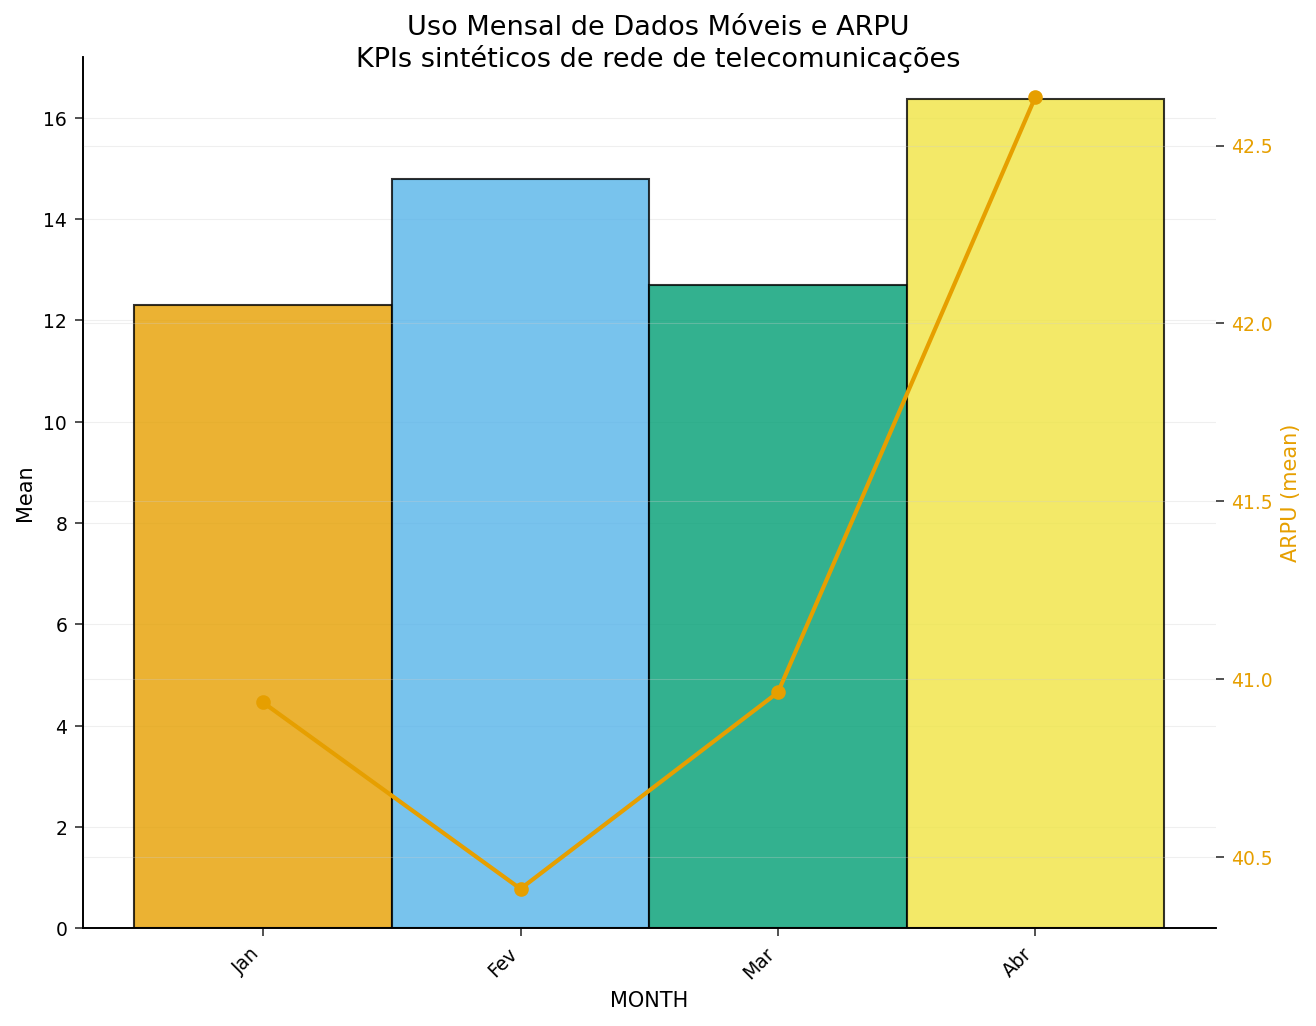

In [2]:
ODS GRAPHICS ON;
TÍTULO "Uso Mensal de Dados Móveis e ARPU";
title2 "KPIs sintéticos de rede de telecomunicações";

PROCEDIMENTO gbarline DADOS=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
EXECUTAR;

## Passo 3 — Decompor o uso por plano, sobrepor cancelamento

Substituir `TYPE=mean` por `TYPE=sum` e adicionar `SUBGROUP=plan` empilha a barra de cada mês por nível de plano, para que possamos ver qual segmento impulsiona o volume total. A `LINE` sobreposta agora plota a **contagem** mensal de eventos de cancelamento como um gráfico de agulhas (`STAT=sum TYPE=needle`) — picos verticais que se leem naturalmente como contagens de eventos discretos em vez de uma tendência suave.

                                   Volume de Dados por Plano com Cancelamento Mensal                                    
                                      KPIs sintéticos de rede de telecomunicações                                       




NOTE: Option TITLE changed to Volume de Dados por Plano com Cancelamento Mensal.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


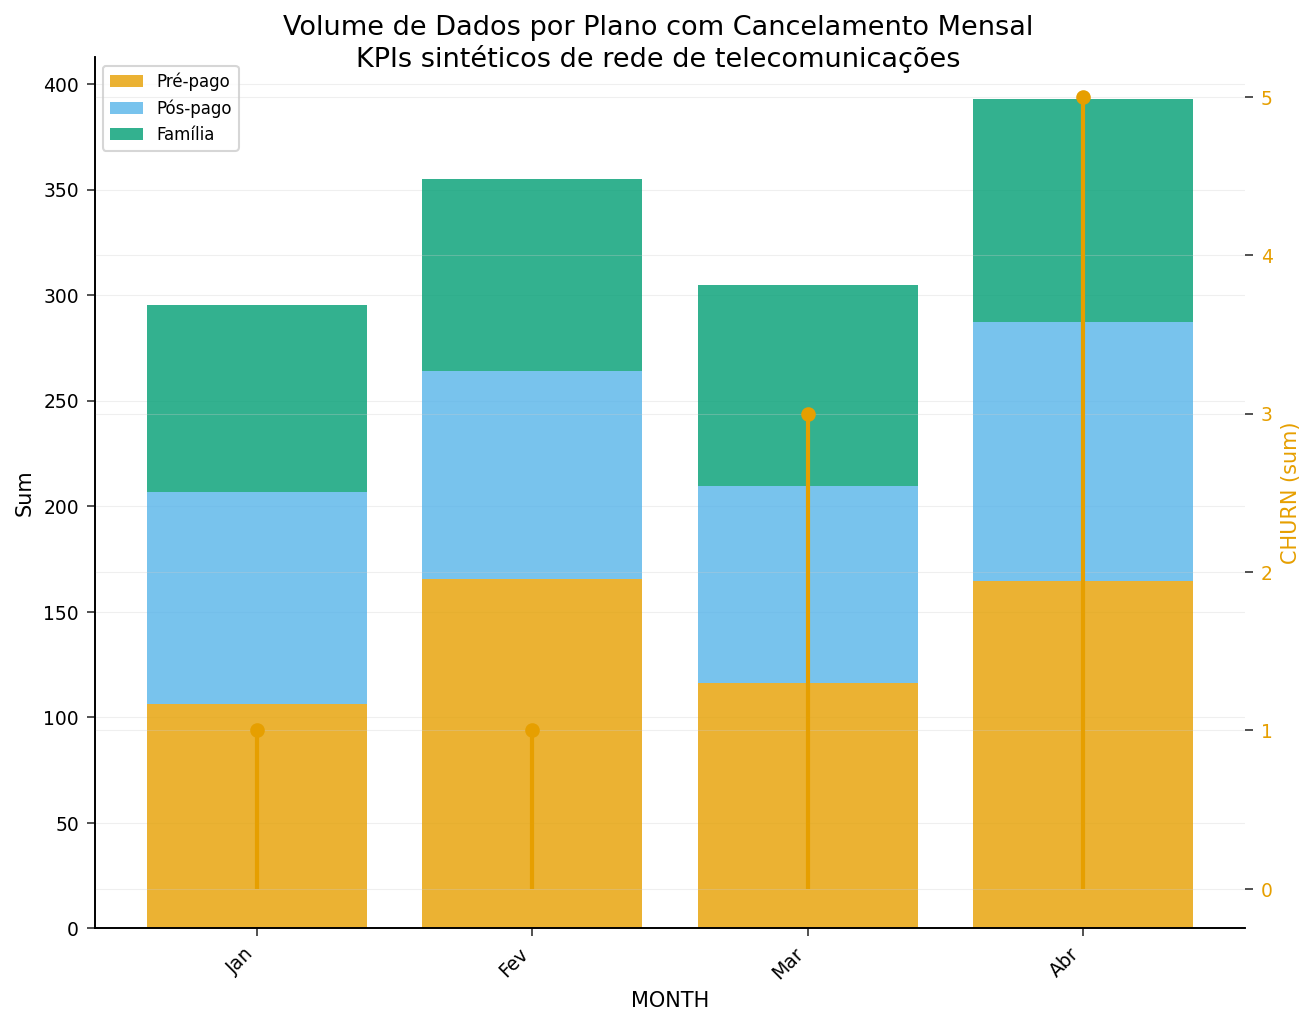

In [3]:
TÍTULO "Volume de Dados por Plano com Cancelamento Mensal";

PROCEDIMENTO gbarline DADOS=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
EXECUTAR;

## Passo 4 — Controlar o eixo direito e o marcador da linha

Para um gráfico pronto para publicação, fixamos o eixo (direito) do gráfico em uma faixa fixa com uma definição `AXIS` e o rotulamos, então o vinculamos à linha via `RAXIS=axis2`. Uma definição `SYMBOL` dá à linha de ARPU um marcador pontilhado vermelho. Também exibimos os totais das barras acima de cada barra com `OUTSIDE=sum`.

                                       Uso Total (barras) vs. ARPU Médio (linha)                                        
                                      KPIs sintéticos de rede de telecomunicações                                       




NOTE: Option TITLE changed to Uso Total (barras) vs. ARPU Médio (linha).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


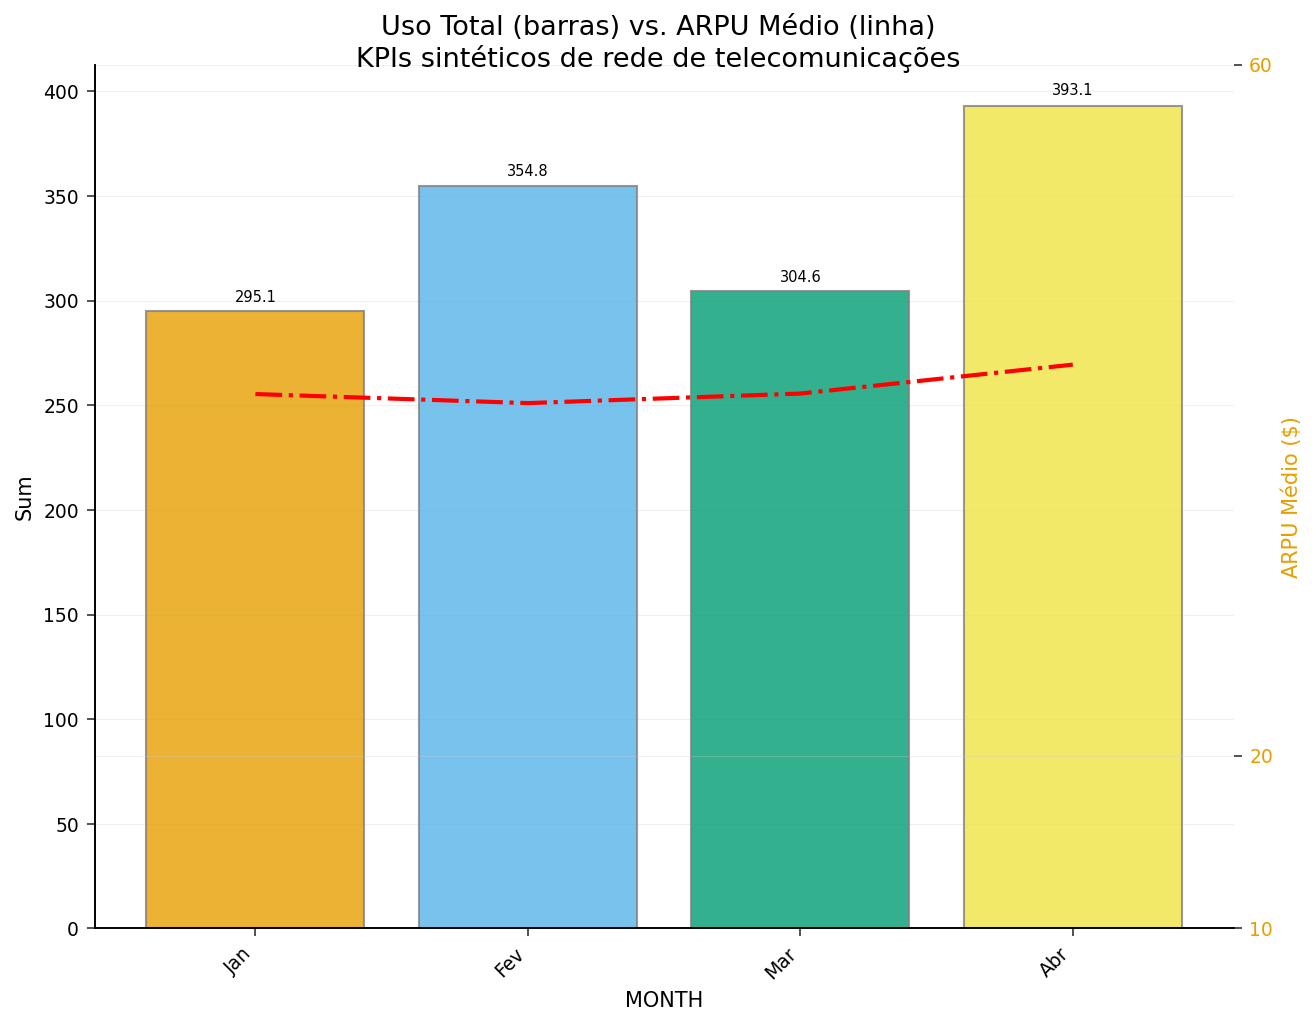

In [4]:
TÍTULO "Uso Total (barras) vs. ARPU Médio (linha)";

PROCEDIMENTO gbarline DADOS=telco_kpi;
    axis2 ORDER=(20 ATÉ 60 POR 10) RÓTULO=("ARPU Médio ($)");
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
EXECUTAR;

## Passo 5 — Sobreposições de múltiplas linhas com uma legenda personalizada

`GBARLINE` aceita mais de uma instrução `LINE`, então podemos comparar dois sinais operacionais contra as barras de uso ao mesmo tempo: chamados de suporte médios (`type=join`) e cancelamento total (`type=needle`). Uma definição `LEGEND` posicionada embaixo documenta os subgrupos de plano.

                                    Tendências de Chamados de Suporte e Cancelamento                                    
                                      KPIs sintéticos de rede de telecomunicações                                       




NOTE: Option TITLE changed to Tendências de Chamados de Suporte e Cancelamento.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


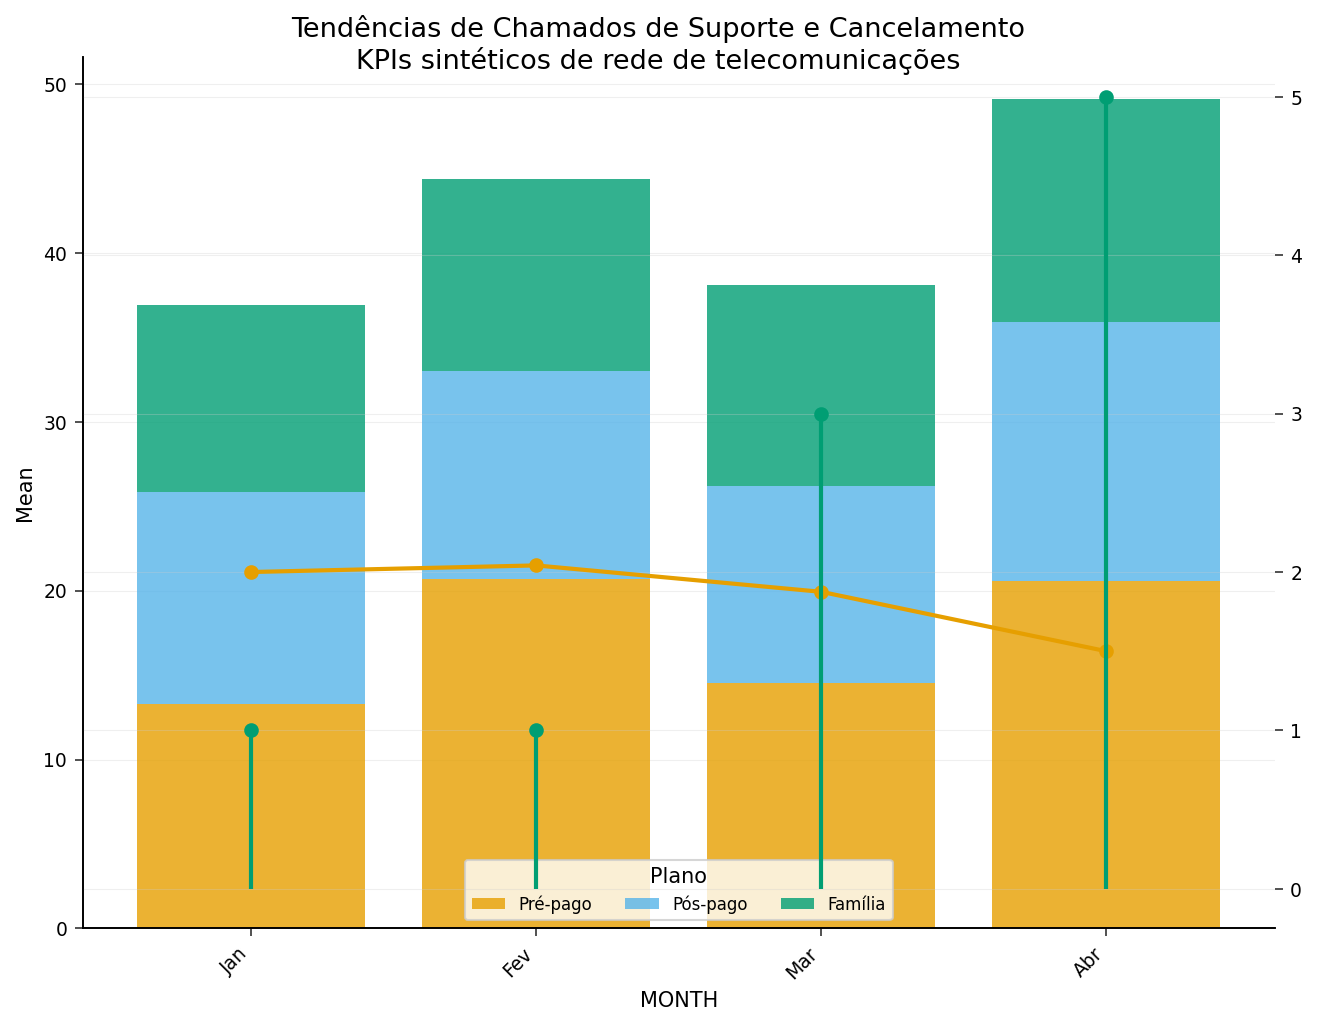

In [5]:
TÍTULO "Tendências de Chamados de Suporte e Cancelamento";

PROCEDIMENTO gbarline DADOS=telco_kpi;
    legend1 RÓTULO=("Plano") position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
EXECUTAR;

ODS GRAPHICS OFF;

## Interpretando os resultados

Ao longo da janela de Jan–Abr, o painel conta uma história coerente de telecom. O **uso de dados** (as barras) é instável mês a mês, mas tende para cima, atingindo o pico em **Abril** — o uso médio sobe de cerca de 12.3 GB em janeiro para 16.4 GB em abril (Passo 2), e o volume total de 295 GB para 393 GB (os rótulos `OUTSIDE=sum` no Passo 4). A **linha de ARPU** cai um pouco em fevereiro e depois sobe até seu próprio pico de abril, perto de \$42.6, então a operadora está cada vez mais monetizando o consumo extra em vez de simplesmente entregá-lo — o eixo direito no Passo 4 é fixado em \$20–\$60 para manter esse movimento legível.

As visões empilhadas por plano (Passos 3 e 5) revelam a tensão de segmento que define operadoras com forte presença de pré-pago. **Pré-pago** (a faixa laranja) carrega a maior quantidade de gigabytes no geral — cerca de 553 GB ao longo dos quatro meses, contra 415 GB para Pós-pago e 380 GB para Família — mas gera a **menor** receita média por usuário (cerca de \$36, contra \$41 para Pós-pago e \$47 para Família). As **agulhas de cancelamento** confirmam onde está o risco de retenção: os eventos de cancelamento se concentram nos níveis Pré-pago e Pós-pago (4 eventos cada ao longo da janela) e ficam mais leves em Família (2), e crescem em direção a abril à medida que a base de assinantes e o uso se expandem.

O Passo 5 sobrepõe a carga operacional a isso: os **chamados de suporte** médios rodam um pouco mais pesados no início do período e diminuem até abril, enquanto as agulhas de cancelamento atingem o pico mais tarde — o tipo de sinal que uma equipe de retenção observa. Operacionalmente, a leitura é concentrar o investimento em retenção nos assinantes **Pré-pago**, que consomem a fatia de volume de dados que mais cresce enquanto geram a menor receita e o maior cancelamento.

`PROC GBARLINE` é a ferramenta certa aqui precisamente porque mantém as barras em escala de gigabytes e as linhas em escala de dólares/contagem em eixos independentes, permitindo que cada KPI seja lido em seus próprios termos, ao mesmo tempo em que compartilha o eixo de tempo mensal.